Sharpe Ratio (Optimized Portfolio - weekly): 0.10
Annualized Sharpe Ratio (Optimized Portfolio): 0.75
Sharpe Ratio (Equally Weighted Portfolio - weekly): 0.07
Annualized Sharpe Ratio (Equally Weighted Portfolio): 0.49
Max Drawdown (Optimized Portfolio - CVaR): 15.61%
Max Drawdown (Equally Weighted Portfolio): 29.61%
Final Cumulative Return (Optimized Portfolio): 1.68
Final Cumulative Return (Equally Weighted Portfolio): 1.42
S&P Sharpe Ratio (weekly): 0.12
S&P Annualized Sharpe Ratio: 0.85
Final Cumulative Return (S&P 500): 2.35


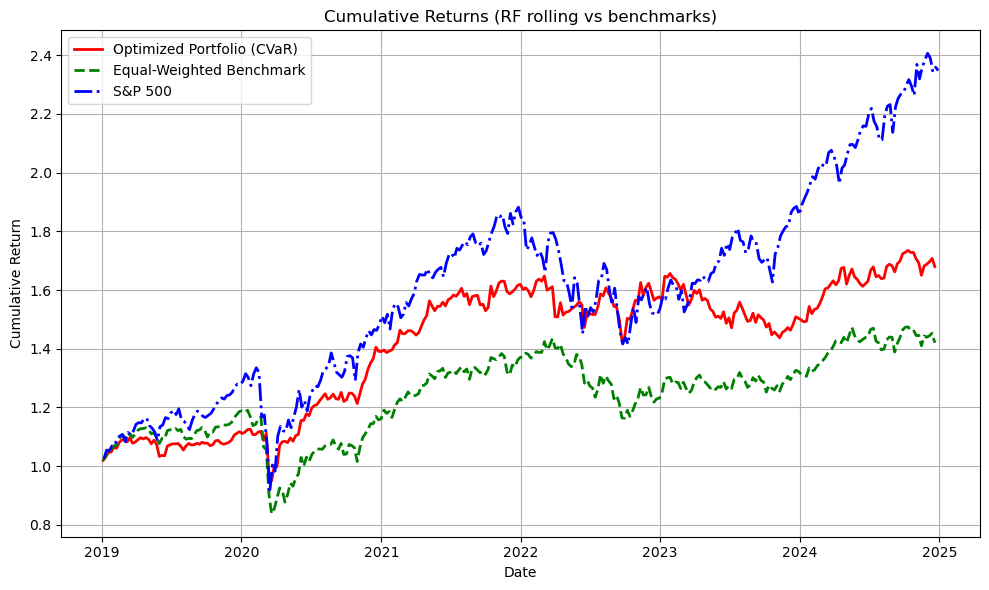

In-Sample Prediction Metrics per Asset:
                 MSE        R2  Directional Accuracy  Spearman  \
es1_logret  0.000026  0.963289              0.949112  0.987299   
vg1_logret  0.000189  0.792298              0.905325  0.919604   
z1_logret   0.000141  0.812040              0.875148  0.926912   
rx1_logret  0.000052  0.524651              0.844970  0.834796   
gc1_logret  0.000129  0.690325              0.871598  0.889654   
co1_logret  0.000963  0.737644              0.868639  0.904709   
hg1_logret  0.000060  0.934016              0.934911  0.975123   

            Best MI Percentile  
es1_logret            0.105017  
vg1_logret            0.061103  
z1_logret             0.056568  
rx1_logret            0.062128  
gc1_logret            0.036571  
co1_logret            0.075339  
hg1_logret            0.061997  
Out-of-Sample Prediction Metrics per Asset:
                 MSE        R2  Directional Accuracy  Spearman  \
es1_logret  0.000433  0.315951              0.743590  0.6

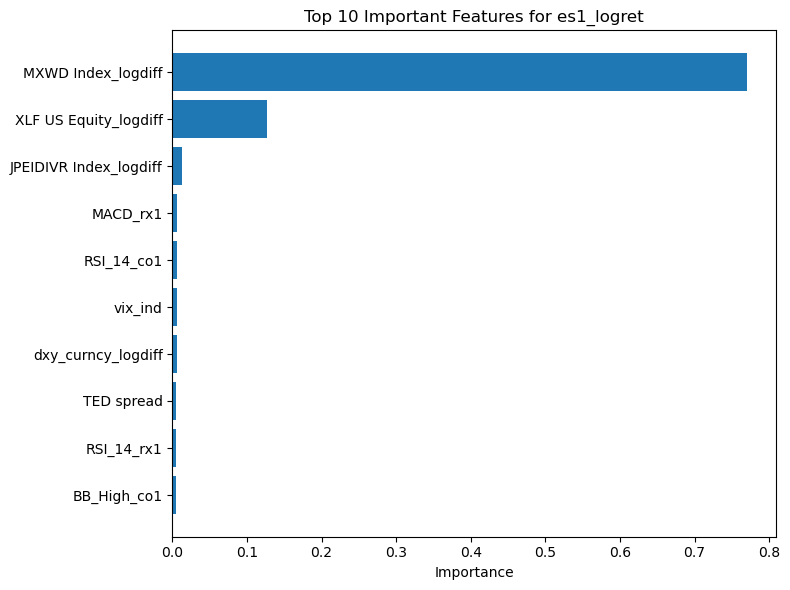

Top 10 features for es1_logret:
                   Feature  Importance
9       MXWD Index_logdiff    0.770167
10   XLF US Equity_logdiff    0.126393
11  JPEIDIVR Index_logdiff    0.013230
18                MACD_rx1    0.006561
26              RSI_14_co1    0.006026
3                  vix_ind    0.005646
8       dxy_curncy_logdiff    0.005472
6               TED spread    0.005374
20              RSI_14_rx1    0.005325
25             BB_High_co1    0.004913


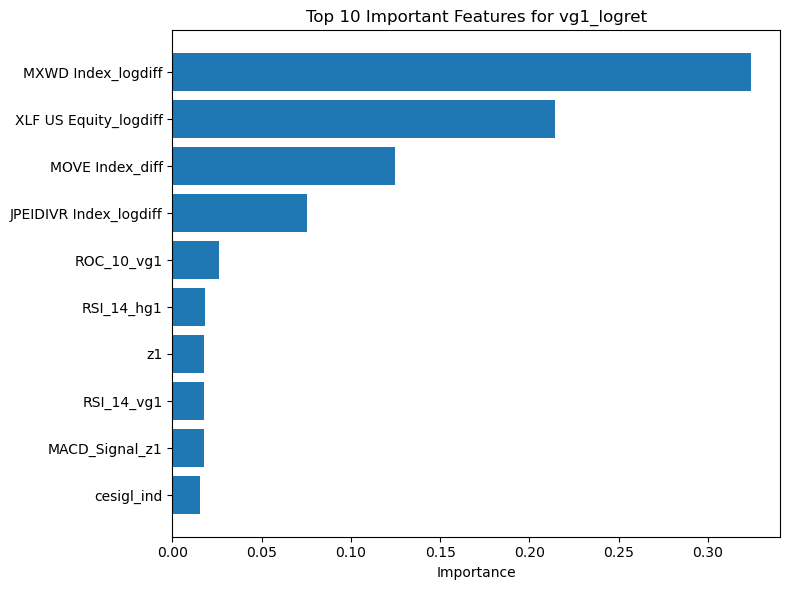

Top 10 features for vg1_logret:
                   Feature  Importance
7       MXWD Index_logdiff    0.324161
9    XLF US Equity_logdiff    0.214073
5          MOVE Index_diff    0.124843
10  JPEIDIVR Index_logdiff    0.075394
18              ROC_10_vg1    0.026082
27              RSI_14_hg1    0.018338
1                       z1    0.017869
17              RSI_14_vg1    0.017736
20          MACD_Signal_z1    0.017662
4               cesigl_ind    0.015485


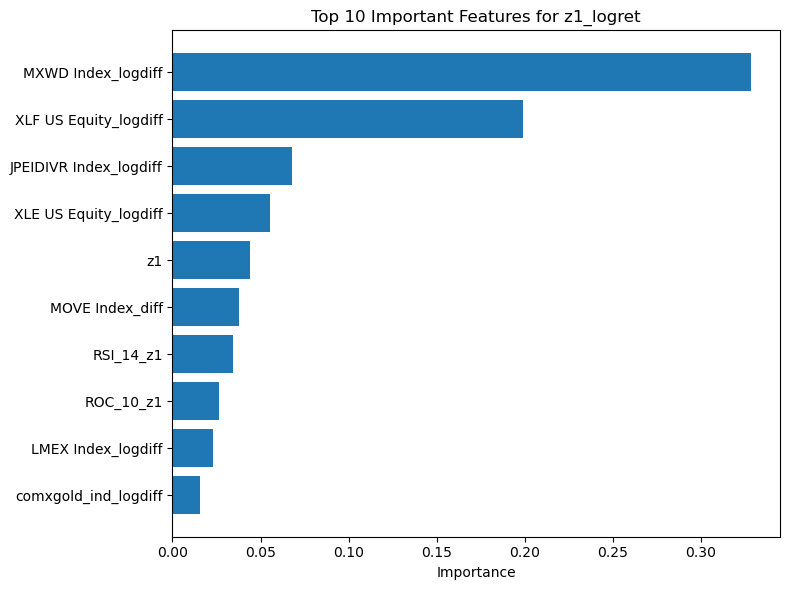

Top 10 features for z1_logret:
                   Feature  Importance
10      MXWD Index_logdiff    0.328518
12   XLF US Equity_logdiff    0.198926
13  JPEIDIVR Index_logdiff    0.068083
11   XLE US Equity_logdiff    0.055512
2                       z1    0.044255
6          MOVE Index_diff    0.037823
20               RSI_14_z1    0.034387
21               ROC_10_z1    0.026212
9       LMEX Index_logdiff    0.022784
7     comxgold_ind_logdiff    0.015905


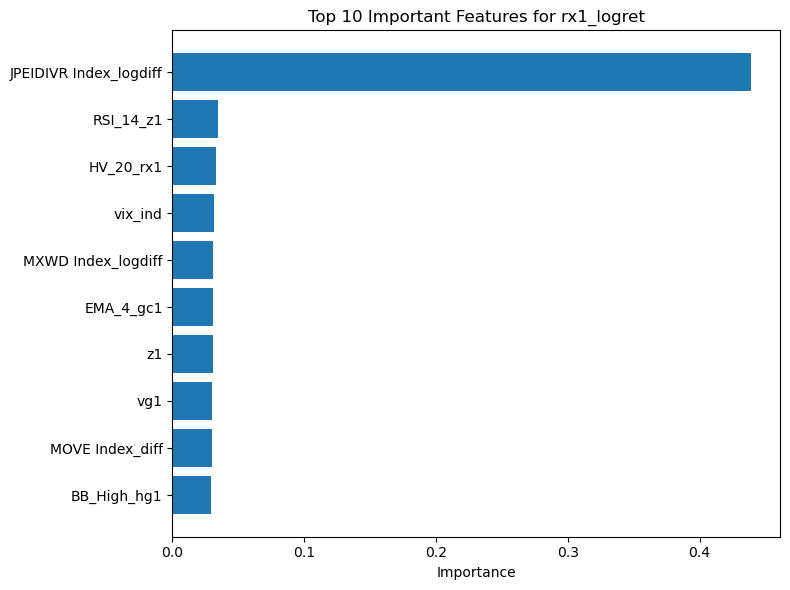

Top 10 features for rx1_logret:
                   Feature  Importance
15  JPEIDIVR Index_logdiff    0.439102
19               RSI_14_z1    0.034202
23               HV_20_rx1    0.033157
12                 vix_ind    0.031654
14      MXWD Index_logdiff    0.030967
24               EMA_4_gc1    0.030873
3                       z1    0.030732
2                      vg1    0.030208
13         MOVE Index_diff    0.029903
28             BB_High_hg1    0.029373


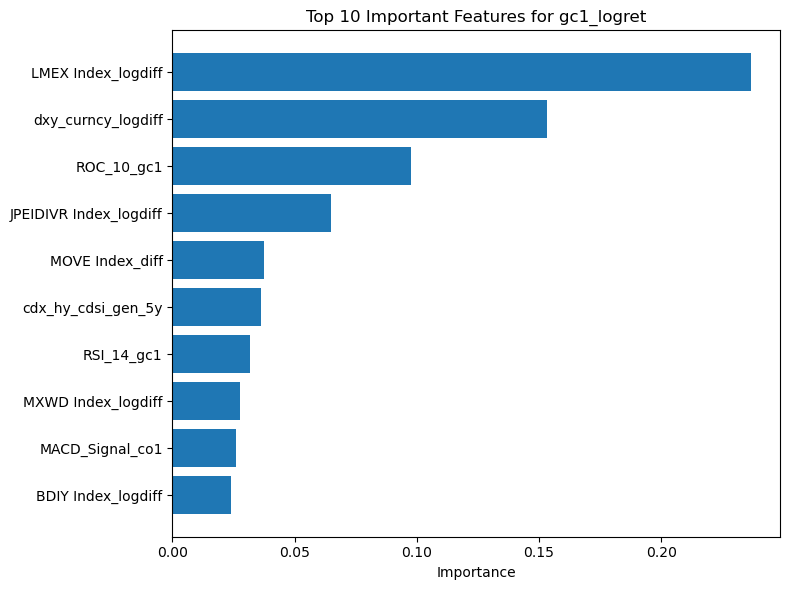

Top 10 features for gc1_logret:
                   Feature  Importance
11      LMEX Index_logdiff    0.236789
10      dxy_curncy_logdiff    0.153074
23              ROC_10_gc1    0.097729
14  JPEIDIVR Index_logdiff    0.064881
9          MOVE Index_diff    0.037262
2       cdx_hy_cdsi_gen_5y    0.036238
22              RSI_14_gc1    0.031535
12      MXWD Index_logdiff    0.027472
26         MACD_Signal_co1    0.025861
13      BDIY Index_logdiff    0.024005


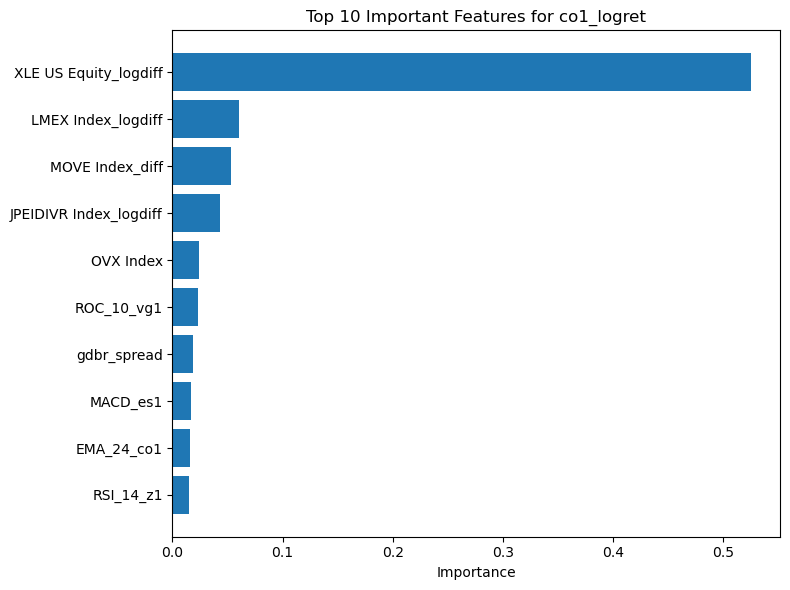

Top 10 features for co1_logret:
                   Feature  Importance
10   XLE US Equity_logdiff    0.525099
9       LMEX Index_logdiff    0.060682
7          MOVE Index_diff    0.052825
11  JPEIDIVR Index_logdiff    0.042689
4                OVX Index    0.024243
17              ROC_10_vg1    0.023123
6              gdbr_spread    0.018566
13                MACD_es1    0.017224
26              EMA_24_co1    0.016155
20               RSI_14_z1    0.015449


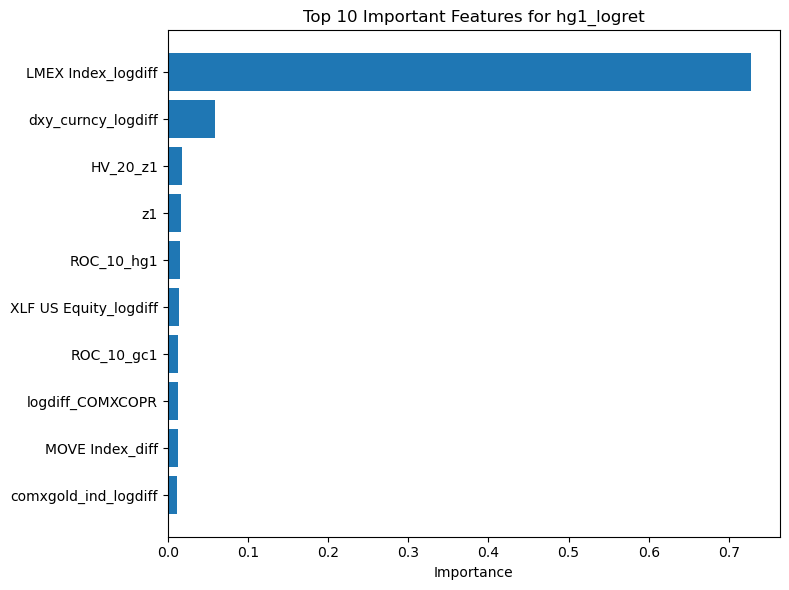

Top 10 features for hg1_logret:
                  Feature  Importance
15     LMEX Index_logdiff    0.727199
12     dxy_curncy_logdiff    0.059486
23               HV_20_z1    0.017974
2                      z1    0.016262
28             ROC_10_hg1    0.015700
16  XLF US Equity_logdiff    0.014395
25             ROC_10_gc1    0.013339
1        logdiff_COMXCOPR    0.013007
11        MOVE Index_diff    0.012744
13   comxgold_ind_logdiff    0.012190


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.feature_selection import mutual_info_regression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import time
import warnings
import os

warnings.filterwarnings("ignore")
np.random.seed(42)
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

start_time = time.time()

###############################################################################
# 1. CVaR, Objective
###############################################################################
def compute_cvar(historical_returns, weights, alpha=0.9):
    
    port_returns = np.dot(historical_returns, weights)
    sorted_returns = np.sort(port_returns)
    cutoff = int(np.floor((1 - alpha) * len(sorted_returns)))
    cutoff = max(cutoff, 0)
    worst_returns = sorted_returns[:cutoff+1]
    cvar = np.mean(worst_returns) if len(worst_returns) > 0 else sorted_returns[cutoff]
    return cvar

def cvar_objective(weights, predicted_returns, historical_returns, alpha=0.9, lambda_reg=0.01):
    
    eps = 1e-8
    port_return = np.dot(weights, predicted_returns)
    port_cvar = compute_cvar(historical_returns, weights, alpha=alpha)
    obj = - port_return / (abs(port_cvar) + eps) + lambda_reg * np.sum(weights**2)
    return obj

###############################################################################
# 2. Define the Random Forest Hyperparameter Search Space
###############################################################################
rf_param_space = {
    'n_estimators': Integer(70, 125),
    'max_depth': Integer(5, 35),
    'min_samples_split': Integer(2, 15),
    'min_samples_leaf': Integer(2, 8),
    'max_features': Real(0.1, 0.9, prior='uniform'),
    'bootstrap': Categorical([True, False]),
    'criterion': Categorical(['friedman_mse'])
}

###############################################################################
# 3.  Data & Containers
###############################################################################
price_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\broader_weekly_data_filled.xlsx',
    parse_dates=["date"],
    index_col="date"
)

filtered_returns = price_data.iloc[:, :7]
filtered_features = price_data.iloc[:, 7:]

# Define training period and testing period
train_start_date = '2015-04-22'
train_end_date   = '2018-12-31'
test_start_date  = '2019-01-01'
test_end_date    = '2025-01-01'

split_date = pd.to_datetime(train_end_date)
split_idx = filtered_returns.index.searchsorted(split_date, side='right')

train_returns_full = filtered_returns.iloc[:split_idx]
test_returns_full  = filtered_returns.iloc[split_idx:]
train_features_full = train_features_full = filtered_features.iloc[:split_idx]
test_features_full  = filtered_features.iloc[split_idx:]

all_returns = pd.concat([train_returns_full, test_returns_full])
all_features = pd.concat([train_features_full, test_features_full])
all_returns.sort_index(inplace=True)
all_features.sort_index(inplace=True)
all_dates = all_returns.index

test_start_idx = len(train_returns_full)

###########################
# Rolling window parameters
###########################

rolling_window_size = 130     
test_window_size = 12         
model_update_frequency_windows = 2  
rebalance_frequency = 2     

# Containers for evaluation
optimized_portfolio_returns_cvar = []
equally_weighted_returns_cvar = []
optimized_weights_list_cvar = []
all_test_dates_collected = []  
all_predictions = []           

train_metrics = {
    asset: {
        "mse": [], "r2": [], "dir_acc": [], "spearman": []
    }
    for asset in train_returns_full.columns
}

mi_threshold_tracker = { asset: [] for asset in train_returns_full.columns }
best_params_tracker = { asset: [] for asset in train_returns_full.columns }

rf_models_bo = {}
trained_features = {} 
last_model_update = -model_update_frequency_windows
window_counter = 0

n_assets = all_returns.shape[1]
prev_opt_weights = np.ones(n_assets) / n_assets
transaction_cost_rate = 0.0001

###############################################################################
# 5. Rolling Window
###############################################################################
for i in range(test_start_idx, len(all_dates) - test_window_size + 1, test_window_size):
    if i - rolling_window_size < 0:
        continue
    train_slice = slice(i - rolling_window_size, i)
    test_slice = slice(i, i + test_window_size)
    
    train_returns_chunk = all_returns.iloc[train_slice]
    train_features_chunk = all_features.iloc[train_slice]
    test_returns_chunk = all_returns.iloc[test_slice]
    test_features_chunk = all_features.iloc[test_slice]
    
    scaler = StandardScaler()
    train_features_scaled_chunk = pd.DataFrame(
        scaler.fit_transform(train_features_chunk),
        index=train_features_chunk.index,
        columns=train_features_chunk.columns
    )
    test_features_scaled_chunk = pd.DataFrame(
        scaler.transform(test_features_chunk),
        index=test_features_chunk.index,
        columns=test_features_chunk.columns
    )

    
    selected_features = {}
    for asset in train_returns_chunk.columns:
        mi_scores = mutual_info_regression(train_features_scaled_chunk, train_returns_chunk[asset], random_state=42)
        threshold = np.percentile(mi_scores, 75)
        mi_threshold_tracker[asset].append(threshold)
        keep_idxs = np.where(mi_scores >= threshold)[0]
        selected_features[asset] = train_features_scaled_chunk.columns[keep_idxs]
    
    if (window_counter - last_model_update) >= model_update_frequency_windows:
        rf_models_bo = {}
        for asset in train_returns_chunk.columns:
            features_for_asset = list(train_features_scaled_chunk[selected_features[asset]].columns)
            trained_features[asset] = features_for_asset 
            
            X_train = train_features_scaled_chunk[selected_features[asset]].values
            y_train = train_returns_chunk[asset].values
            if X_train.shape[0] > 0 and X_train.shape[1] > 0:
                opt = BayesSearchCV(
                    RandomForestRegressor(random_state=42),
                    rf_param_space,
                    n_iter=25,
                    cv=TimeSeriesSplit(n_splits=3),
                    n_jobs=-1,
                    scoring='neg_mean_squared_error',
                    random_state=42
                )
                opt.fit(X_train, y_train)
                best_model = opt.best_estimator_
                rf_models_bo[asset] = best_model
                
                best_params_tracker[asset].append(opt.best_params_)
                
                # In-sample metrics.
                y_train_pred = best_model.predict(X_train)
                mse_val = mean_squared_error(y_train, y_train_pred)
                r2_val = r2_score(y_train, y_train_pred)
                train_metrics[asset]["mse"].append(mse_val)
                train_metrics[asset]["r2"].append(r2_val)
                actual_dir = np.sign(y_train)
                predicted_dir = np.sign(y_train_pred)
                train_metrics[asset]["dir_acc"].append(np.mean(actual_dir == predicted_dir))
                spearman_corr, _ = spearmanr(y_train, y_train_pred)
                train_metrics[asset]["spearman"].append(spearman_corr)
        last_model_update = window_counter

    # Predict returns
    predictions_df = pd.DataFrame(index=test_returns_chunk.index,
                                  columns=test_returns_chunk.columns)
    for asset in test_returns_chunk.columns:
        X_test_asset = test_features_scaled_chunk.reindex(columns=selected_features[asset], fill_value=0)
        if asset in rf_models_bo and X_test_asset.shape[1] > 0:
            predictions_df[asset] = rf_models_bo[asset].predict(X_test_asset)
        else:
            predictions_df[asset] = 0.0
    all_predictions.append(predictions_df.copy())
    
    # For each observation in the test chunk, rebalance
    for j in range(len(test_returns_chunk)):
        date_j = test_returns_chunk.index[j]
        all_test_dates_collected.append(date_j)
        
        if j == 0:
            w_opt = prev_opt_weights
        else:
            expected_returns = predictions_df.iloc[j-1].fillna(0).values
            historical_returns_scenarios = train_returns_chunk.values
            n_assets = len(expected_returns)
            init_guess = np.ones(n_assets) / n_assets
            bounds = [(0, 1)] * n_assets
            constraints = [
                {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                {'type': 'ineq', 'fun': lambda w: 0.4 - np.max(w)},
                {'type': 'ineq', 'fun': lambda w: np.min(w) - 0.0}
            ]
            
            # Rebalance
            if (j-1) % rebalance_frequency == 0:
                res = minimize(
                    cvar_objective,
                    init_guess,
                    args=(expected_returns, historical_returns_scenarios, 0.95, 0.01),
                    method='SLSQP',
                    bounds=bounds,
                    constraints=constraints
                )
                w_opt = res.x if res.success else init_guess
            else:
                w_opt = prev_opt_weights
        
        turnover = np.sum(np.abs(w_opt - prev_opt_weights))
        cost = transaction_cost_rate * turnover
        realized_return = test_returns_chunk.iloc[j].values
        port_return_opt = np.dot(w_opt, realized_return)
        net_return = port_return_opt - cost

        optimized_portfolio_returns_cvar.append(net_return)
        eq_weights = np.ones(n_assets) / n_assets
        eq_return = np.dot(eq_weights, realized_return)
        equally_weighted_returns_cvar.append(eq_return)
        optimized_weights_list_cvar.append(w_opt)
        prev_opt_weights = w_opt.copy()
    
    window_counter += 1

###############################################################################
# 6. Cumulative returns and performance metrics
###############################################################################
optimized_cumulative_returns = (1 + np.array(optimized_portfolio_returns_cvar)).cumprod()
equally_weighted_cumulative_returns = (1 + np.array(equally_weighted_returns_cvar)).cumprod()

def calculate_sharpe_ratio(returns, risk_free_rate=0):
    excess_returns = np.array(returns) - risk_free_rate
    return np.mean(excess_returns) / (np.std(excess_returns, ddof=1) + 1e-9)

def calculate_max_drawdown(cum_returns):
    cumulative_max = np.maximum.accumulate(cum_returns)
    drawdowns = (cumulative_max - cum_returns) / cumulative_max
    return np.max(drawdowns)


sharpe_optimized = calculate_sharpe_ratio(optimized_portfolio_returns_cvar)
sharpe_equal = calculate_sharpe_ratio(equally_weighted_returns_cvar)
annualized_sharpe_optimized = sharpe_optimized * np.sqrt(52)
annualized_sharpe_equal = sharpe_equal * np.sqrt(52)

max_drawdown_optimized = calculate_max_drawdown(optimized_cumulative_returns)
max_drawdown_equal = calculate_max_drawdown(equally_weighted_cumulative_returns)

final_optimized_cum_return = optimized_cumulative_returns[-1]
final_equal_cum_return = equally_weighted_cumulative_returns[-1]

print(f"Sharpe Ratio (Optimized Portfolio - weekly): {sharpe_optimized:.2f}")
print(f"Annualized Sharpe Ratio (Optimized Portfolio): {annualized_sharpe_optimized:.2f}")
print(f"Sharpe Ratio (Equally Weighted Portfolio - weekly): {sharpe_equal:.2f}")
print(f"Annualized Sharpe Ratio (Equally Weighted Portfolio): {annualized_sharpe_equal:.2f}")
print(f"Max Drawdown (Optimized Portfolio - CVaR): {max_drawdown_optimized:.2%}")
print(f"Max Drawdown (Equally Weighted Portfolio): {max_drawdown_equal:.2%}")
print(f"Final Cumulative Return (Optimized Portfolio): {final_optimized_cum_return:.2f}")
print(f"Final Cumulative Return (Equally Weighted Portfolio): {final_equal_cum_return:.2f}")

###############################################################################
# 7. S&P returns
###############################################################################
sp_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\s_p_ret.xlsx',
    parse_dates=["date"],
    index_col="date"
)
sp_returns = sp_data['sp_ret']
sp_returns = sp_returns.loc[test_start_date:test_end_date]
sp_cumulative_returns = (1 + sp_returns).cumprod()
sharpe_sp = calculate_sharpe_ratio(sp_returns)
annualized_sharpe_sp = sharpe_sp * np.sqrt(52)
final_sp_cum_return = sp_cumulative_returns.iloc[-1]
print(f"S&P Sharpe Ratio (weekly): {sharpe_sp:.2f}")
print(f"S&P Annualized Sharpe Ratio: {annualized_sharpe_sp:.2f}")
print(f"Final Cumulative Return (S&P 500): {final_sp_cum_return:.2f}")

###############################################################################
# 8. Plot
###############################################################################
plt.figure(figsize=(10, 6))
plt.plot(all_test_dates_collected, optimized_cumulative_returns, label='Optimized Portfolio (CVaR)', color='red', linewidth=2)
plt.plot(all_test_dates_collected, equally_weighted_cumulative_returns, label='Equal-Weighted Benchmark', color='green', linestyle='--', linewidth=2)
plt.plot(sp_cumulative_returns.index, sp_cumulative_returns, label='S&P 500', color='blue', linestyle='-.', linewidth=2)
plt.title('Cumulative Returns (RF rolling vs benchmarks)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

###############################################################################
# 9. Compute in-sample and out-of-sample metrics 
###############################################################################
in_sample_summary_df = pd.DataFrame({
    asset: {
        "MSE": np.mean(metrics["mse"]) if metrics["mse"] else None,
        "R2": np.mean(metrics["r2"]) if metrics["r2"] else None,
        "Directional Accuracy": np.mean(metrics["dir_acc"]) if metrics["dir_acc"] else None,
        "Spearman": np.mean(metrics["spearman"]) if metrics["spearman"] else None,
        "Best MI Percentile": np.mean(mi_threshold_tracker[asset]) if mi_threshold_tracker[asset] else None
    } for asset, metrics in train_metrics.items()
}).T
print("In-Sample Prediction Metrics per Asset:")
print(in_sample_summary_df)

predicted_returns_df = pd.concat(all_predictions).sort_index()
actual_returns = all_returns.loc[predicted_returns_df.index]

out_sample_metrics = {}
for asset in actual_returns.columns:
    y_true = actual_returns[asset]
    y_pred = predicted_returns_df[asset]
    mse_val = mean_squared_error(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)
    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    spearman_corr, _ = spearmanr(y_true, y_pred)
    out_sample_metrics[asset] = {
        "MSE": mse_val,
        "R2": r2_val,
        "Directional Accuracy": directional_accuracy,
        "Spearman": spearman_corr,
        "Best MI Percentile": np.mean(mi_threshold_tracker[asset]) if mi_threshold_tracker[asset] else None
    }
out_sample_metrics_df = pd.DataFrame(out_sample_metrics).T
print("Out-of-Sample Prediction Metrics per Asset:")
print(out_sample_metrics_df)

end_time = time.time()
print("Total processing time: {:.0f} min".format((end_time - start_time) / 60))

###############################################################################
# 11. Top 10 important features
###############################################################################
save_folder = r'C:\Users\orekh\Desktop\MMF\Thesis\Data\saved_for_graphs\rf_rolling'
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

for asset, model in rf_models_bo.items():
    features_used = trained_features.get(asset)
    if features_used is None:
        print(f"No stored features for {asset}. Skipping.")
        continue

    importances = model.feature_importances_
    if len(features_used) != len(importances):
        print(f"Skipping asset {asset} due to mismatch: {len(features_used)} features vs {len(importances)} importance scores.")
        continue

    importance_df = pd.DataFrame({
        'Feature': features_used,
        'Importance': importances
    })
    
    top_10 = importance_df.sort_values('Importance', ascending=False).head(10)
    top_10_sorted = top_10.sort_values('Importance')
    
    plt.figure(figsize=(8, 6))
    plt.barh(top_10_sorted['Feature'], top_10_sorted['Importance'])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Important Features for {asset}')
    plt.tight_layout()
    save_path = os.path.join(save_folder, f'top10_features_{asset}.png')
    plt.savefig(save_path)
    plt.show()
    
    print(f"Top 10 features for {asset}:")
    print(top_10)